# MAX IV phase retrieval
Run after `00_prepare_maxiv.py` and `03_maxiv_supportmask.ipynb`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'library'))
import fth_phase_workflow as wf
import fthcore as fth
import phase_retrieval_core_unified as pr
DATA_H5 = ROOT / 'processed/Logs/data_recon_ImId_1143_maxiv.hdf5'
data = wf.load_data_dict(DATA_H5)
supportmask = np.asarray(data['supportmask'])
mask_pixel = np.asarray(data['mask_pixel'])*0
holograms = {label: np.asarray(data['holo'][label]['image_c']) for label in ('+', '-')}

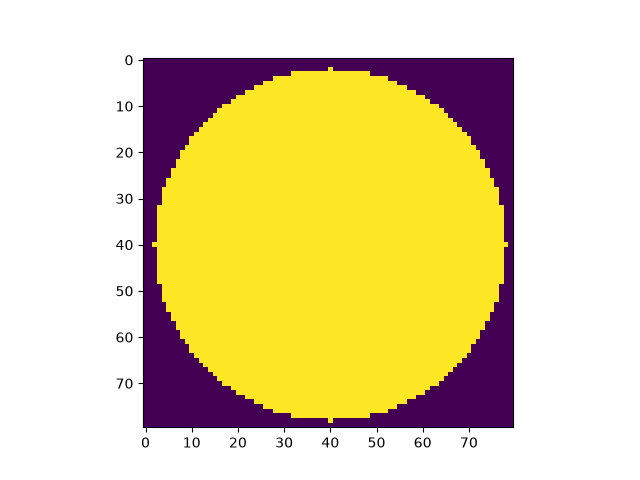

In [4]:
%matplotlib widget
plt.close("all")
fig,ax=plt.subplots()
ax.imshow(np.abs(supportmask)[892: 972, 1110: 1190], vmin=0, vmax=1)

In [5]:
# Short first pass; increase these counts after checking the mask overlay.
recipe = {
    'algorithm_list': ['HAPRE', 'ER', 'ER','HAPRE', 'ER', 'ER'],
    'number_iterations': [700, 50, 50, 700, 50,50],
    'helicity': ['+', '+', '-','+', '+', '-'],
    "beta_zero": 0.5,
    'beta_mode': ['arctan', 'const', 'const','arctan', 'const', 'const'],
    'alpha_zero': 0.0,
    'alpha_mode': 'const',
    'RL_its': [0, 0, 0, 50,50,50],
    'RL_freqs': [1e9, 1e9, 1e9,20,20,20],
    'TV_freqs': 1e9,
    'plot_every': 1e9,
    'average_img': 10,
    "Fourier_last": True,
    'Startimage': [None, '+', '+','+', '+','+'],
    'Startgamma': [None, None, None, None, "+","+"],
    'hologram_intensity_cutoff_vmin': 0.01,
    'hologram_offset': 0.0,
    'output': [False, True, True, False, True,True],
    "modes": [1,2],
    'normalize_startimage_between_holograms': False,
    "subtract_startimage_fit_intercept": False,  # Preserve the initial Fourier phase.
    'return_format': 'dict',
    'crop': 248,
    'binning': 2,
    'roi': [892, 972, 1110, 1190],
}
from retrieval_progress import retrieval_progress
with retrieval_progress(recipe, kind="unified"):
    result = pr.phase_retrieval_algorithm(holograms, mask_pixel, supportmask, recipe)


Step 0: helicity=+, mode=HAPRE, Nit=700, full coherence, Nmodes=2
Step 1: helicity=+, mode=ER, Nit=50, full coherence, Nmodes=2
Step 2: helicity=-, mode=ER, Nit=50, full coherence, Nmodes=2
Step 3: helicity=+, mode=HAPRE, Nit=700, partial coherence, Nmodes=2
Step 4: helicity=+, mode=ER, Nit=50, partial coherence, Nmodes=2
Step 5: helicity=-, mode=ER, Nit=50, partial coherence, Nmodes=2
--- 45.15 seconds ---
Phase Retrieval Done!


**ROI coordinates.** `recipe["crop"]` removes full-resolution detector pixels before `recipe["binning"]` sums complete blocks. The detector mask follows the same slices and bins. The object support is resampled for the reduced detector extent, then mapped to the resulting grid; `recipe["roi"]` starts in the original 2048×2048 support coordinates and follows the same scale and center. With binning=2 and crop=248, the returned grid is 776×776, and `[892, 972, 1110, 1190]` maps to `[288, 348, 453, 514]`. Use `result["roi"]` with `reconstructCDI`.


In [6]:
RETRIEVED_KIND = 'partial_coherence'  # Use 'full_coherence' to compare with the old two-mode example.
retrieved = result[RETRIEVED_KIND]
print('Retrieved:', {label: np.asarray(retrieved[label]).shape for label in ('+', '-')})

Retrieved: {'+': (2, 528, 528), '-': (2, 528, 528)}


In [7]:
FOCUS_MODE = 0  # Mode index for 3D reconstructions.
def focus_field(field, label):
    field = np.asarray(field)
    if field.ndim == 2:
        return field.copy()
    if field.ndim == 3:
        if not 0 <= FOCUS_MODE < field.shape[0]:
            raise IndexError(f'{label} has {field.shape[0]} modes; requested {FOCUS_MODE}.')
        return field[FOCUS_MODE].copy()
    raise ValueError(f'{label} must be 2D or 3D, got shape {field.shape}.')

In [8]:
print('Full-coherence shapes:', {label: np.asarray(result['full_coherence'][label]).shape for label in ('+', '-')})
print('Partial-coherence shapes:', {label: np.asarray(result['partial_coherence'][label]).shape for label in ('+', '-')})

Full-coherence shapes: {'+': (2, 528, 528), '-': (2, 528, 528)}
Partial-coherence shapes: {'+': (2, 528, 528), '-': (2, 528, 528)}


In [9]:
roi_s=wf.roi_to_slices(result['roi'])

In [10]:
plt.close("all")

In [14]:
used_support = focus_field(result['supportmask_used'], 'supportmask_used')
plot_support = focus_field(result['supportmask'], 'supportmask')
plot_field = focus_field(result['full_coherence']['+'], '+')
object_magnitude = np.abs(fth.reconstructCDI(plot_field))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(used_support, cmap='gray')
axes[0].set_title(f'Support passed to kernel ({used_support.shape})')
axes[1].imshow(plot_support, cmap='gray')
axes[1].set_title(f'Support on returned field grid ({plot_support.shape})')
axes[2].imshow(np.log1p(object_magnitude), cmap='magma')
axes[2].contour(plot_support, levels=[0.5], colors='cyan', linewidths=0.6)
axes[2].set_title(f'FT of returned field, mode {FOCUS_MODE}')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

In [17]:
plt.close("all")
%matplotlib qt
import reconstruct_rb as rec
focus_sliders_by_coherence = {}
for coherence in ('full_coherence', 'partial_coherence')[1:]:
    collection = result[coherence]
    if collection['+'] is None or collection['-'] is None:
        print(coherence, 'is not available for both helicities')
        continue
    temp_p = focus_field(collection['+'], '+')
    temp_n = focus_field(collection['-'], '-')
    print('Focusing', coherence, 'with fields', temp_p.shape, temp_n.shape)
    focus_sliders_by_coherence[coherence] = rec.focusCDI(
        temp_p, temp_n,
        roi_s,
        mask=(focus_field(result['supportmask'], 'supportmask')),
        phase=0, dx=0, dy=0, prop_dist=0,
        operation='-', max_prop_dist=10, scale=(0, 100),
    )
    plt.gcf().suptitle(coherence.replace('_', ' ').title())
focus_sliders = focus_sliders_by_coherence.get(RETRIEVED_KIND)

Focusing partial_coherence with fields (528, 528) (528, 528)


interactive(children=(FloatSlider(value=0.0, description='propagation[um]', layout=Layout(width='90%'), max=10…

In [10]:
plt.close("all")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, label in enumerate(('+', '-')):
    field_modes = wf.as_modes(retrieved[label])
    intensity = np.asarray(holograms[label], dtype=float) - result['hologram_offsets'][label]
    vmin = recipe['hologram_intensity_cutoff_vmin']
    if vmin >= 0:
        valid = intensity[(intensity != 0) & np.isfinite(intensity)]
        if valid.size:
            intensity -= np.nanpercentile(valid, vmin)
    target = np.sqrt(np.clip(np.nan_to_num(intensity), 0, None))
    if RETRIEVED_KIND == 'partial_coherence':
        gamma_modes = wf.as_modes(result['gamma'][label])
        model_corner = np.zeros(target.shape, dtype=complex)
        for field_mode, gamma_mode in zip(field_modes, gamma_modes):
            corner_field = np.fft.fftshift(field_mode)
            corner_gamma = np.fft.fftshift(gamma_mode)
            model_corner += np.fft.ifft2(
                np.fft.fft2(np.abs(corner_field) ** 2) * np.fft.fft2(corner_gamma)
            )
        model = np.fft.ifftshift(model_corner)
        predicted = np.sqrt(np.clip(np.real(model), 0, None))
        print(label, 'RL model imaginary fraction:', float(np.linalg.norm(np.imag(model)) / max(np.linalg.norm(np.abs(model)), 1e-30)))
    else:
        predicted = np.sqrt(np.sum(np.abs(field_modes) ** 2, axis=0))
    observed = np.asarray(result['bsmasks'][label]) == 0
    rms = np.sqrt(np.mean((predicted[observed] - target[observed]) ** 2))
    scale = np.sqrt(np.mean(target[observed] ** 2))
    print(label, 'relative observed-amplitude RMS:', float(rms / scale))
    object_modes = np.stack([fth.reconstructCDI(mode) for mode in field_modes])
    object_amplitude = np.sqrt(np.sum(np.abs(object_modes) ** 2, axis=0))
    amplitude_max = np.percentile(np.log1p(target), 99.9)
    axes[row, 0].imshow(np.log1p(target), cmap='gray', vmin=0, vmax=amplitude_max)
    axes[row, 1].imshow(np.log1p(predicted), cmap='gray', vmin=0, vmax=amplitude_max)
    axes[row, 2].imshow(np.log1p(object_amplitude), cmap='gray')
    for ax, title in zip(axes[row], ('measured amplitude', 'RL model amplitude', 'object amplitude')):
        ax.set_title(label + ' ' + title); ax.set_axis_off()
plt.tight_layout()
fig.savefig(ROOT / 'processed/phase_diagnostic_1143.png', dpi=120)
plt.show()


+ RL model imaginary fraction: 0.008519889357688807
+ relative observed-amplitude RMS: 0.14816994020662144
- RL model imaginary fraction: 0.004272161982320928
- relative observed-amplitude RMS: 0.1526179145101683


In [11]:
for label in ('+', '-'):
    for name, collection in (('retrieved_full', result['full_coherence']), ('retrieved_pc', result['partial_coherence'])):
        if collection[label] is not None:
            data['holo'][label][name] = np.asarray(collection[label])
    data['holo'][label]['bsmask'] = np.asarray(result['bsmasks'][label])
    data['holo'][label]['gamma'] = np.asarray(result['gamma'][label])
    data['holo'][label]['recon_cdi'] = np.stack([fth.reconstructCDI(mode) for mode in wf.as_modes(retrieved[label])])
data['phase_retrieval_recipe'] = recipe
OUTPUT_H5 = ROOT / 'processed/Logs/data_phase_ImId_1143_maxiv.hdf5'
wf.save_data_dict(data, OUTPUT_H5, overwrite=True)
print('Saved:', OUTPUT_H5)


Saved: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/maxiv_phase_test/processed/Logs/data_phase_ImId_1143_maxiv.hdf5
